![](../images/logos/KIEPSKIES.jpg)

# Dimensionality Reduction 
## **Introduction**

Dimensionality Reduction is the process of reducing the number of features (variables) in a data set while retiaing as much useful information as possible. High-dimensional data can be complex, slow to process, and prone to overfitting, making it harder to analyze and visualize. 

In simple terms, imagine you are a teacher evaluating students. You collect 100 different characteristics(e.g height, favourite color, handwriting style, choice of seat etc.) to predict student performance. However not all 100 features matter- probably only 5-10 features(like studey hours, test scores and attendance) are important. Dimensionality reudction helps you identify and fosuc on these key features while ignoring unnecessary detials. 

Here is why dimensionality reduction is important; 

- *Reduces computation time* - fewer features mean faster processing.
- *Avoids overfitting* - helps models generalize better by removing redudant information/
- *Improves visualization* - High dimensional data is hard to interpret, reducing to 2D or 3D makes it easier.
- *Removes noise* - Elminites irrelevant or redudant features.

There are two main types of dimensionlity reduction; 

1. **Feature selection** - choosing the most important features and discarding the rest. Examples are variance thresholdm correlation analysis and recursive feature elimination(RFE).
2. **Feature Extraction** - Transforming high-dimensional data into a lower-dimensional representation. Some of the methods include;

- *Principal Component Analysis*(PCA) - projects data into a new space to maximize variance.
- *Linear Discrimnant Analysis*(LDA) - maximizes class separability.
- Truncated Singular Value Decomposition*(Truncated SVD) - similar to PCa but used for sparse data.
- *t-SNE & UMAP* - Used for visualizing high-dimensional data. 

## **Linear Discriminant Analysis** (LDA)

This is a supervised dimensionality reduction technique that finds a lower-dimensional space while maximizing class separability. Unlike PCA which maximizes variance, LDA maximizes ratio between-class variance to within-class variance.

In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the data 
digits = load_digits()

X = digits.data
y = digits.target

print("Shape of the dataset: ", X.shape)

Shape of the dataset:  (1797, 64)


In [3]:
# Apply LDA 
## Standardize the data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply LDA to reduce the data set to two dimensions 
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

## Convert to a dataframe 
lda_df = pd.DataFrame(X_lda, columns=["Component 1", "Component 2"])
lda_df["target"] = y

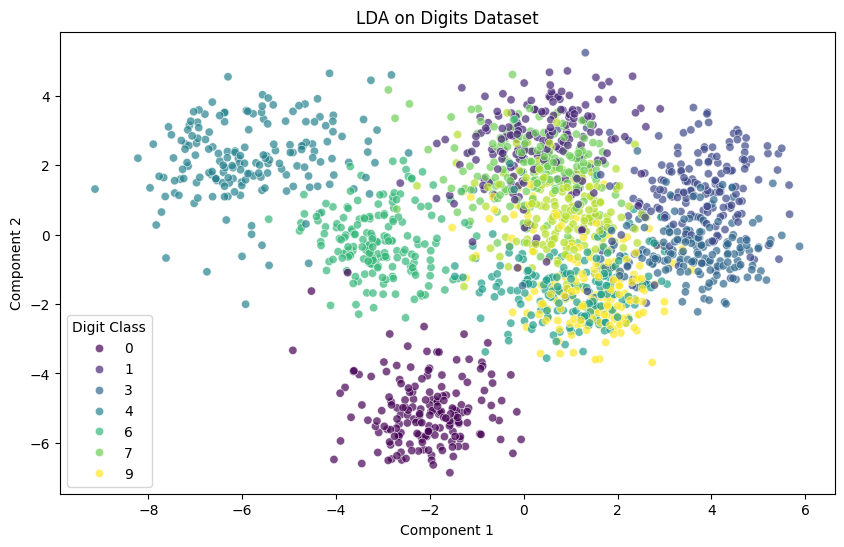

In [4]:
# Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(data=lda_df,
               x = 'Component 1', y = "Component 2", 
               hue = "target", palette = "viridis", alpha = 0.7)
plt.title("LDA on Digits Dataset")
plt.legend(title="Digit Class")
plt.show()

## **Principal Component Analysis** 

In [5]:
from sklearn.decomposition import PCA

In [6]:
# Load Digits dataset
digits = load_digits()
X = digits.data  # Feature matrix
y = digits.target  # Labels

In [7]:
# Standardize data (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Apply PCA, keeping 95% variance
pca = PCA(n_components=0.95)  # Retains 95% variance
X_pca = pca.fit_transform(X_scaled)

In [9]:
# Print new shape
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_pca.shape}")


Original shape: (1797, 64)
Reduced shape: (1797, 40)


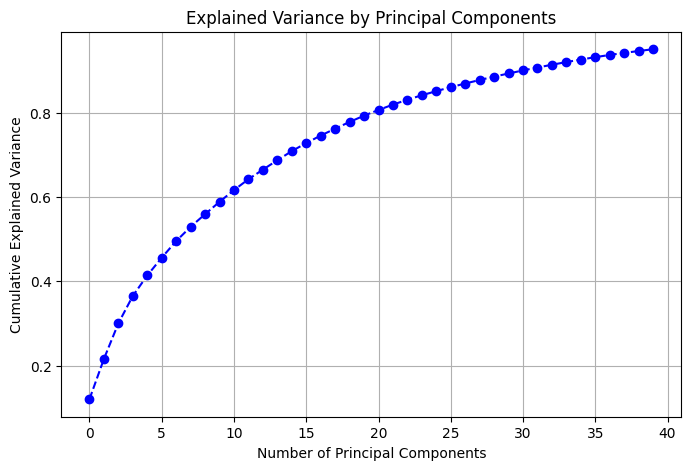

In [10]:
# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.grid()
plt.show()

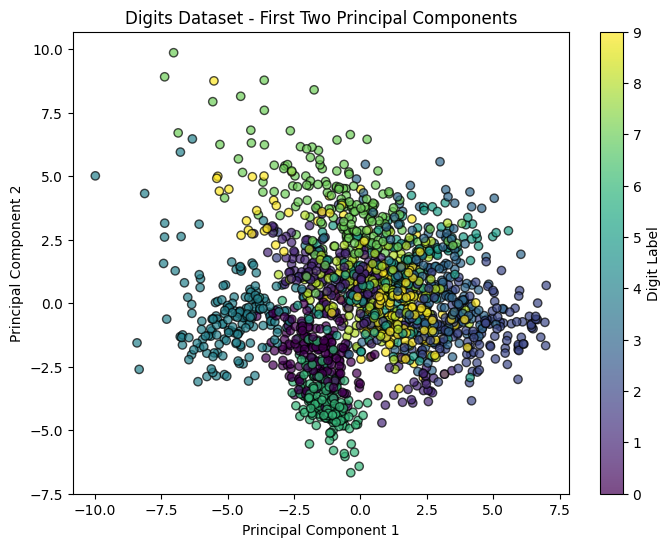

In [11]:
# Visualizing the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Digits Dataset - First Two Principal Components")
plt.colorbar(label="Digit Label")
plt.show()

The dataset originally had 64 features (8x8 pixel images).

- PCA reduced it to ~30 components while retaining 95% of the information.

- The explained variance plot shows how many components are needed to keep most of the information.

- The scatter plot shows how digits cluster using only the first two principal components.

## **Truncated SVD**

Truncated Singular Value Decomposition (SVD) is a dimensionality reduction technique similar to PCA, but it works directly on sparse or high-dimensional data. Unlike PCA, it does not require centering the data. It is commonly used in text processing (Latent Semantic Analysis - LSA) and image compression.

In [12]:
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import fetch_openml

# Load Fashion MNIST dataset
fashion_mnist = fetch_openml('Fashion-MNIST', version=1)
X, y = fashion_mnist.data, fashion_mnist.target.astype(int)

In [13]:
from sklearn.preprocessing import MinMaxScaler

#Scale the data set
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Apply Truncated SVD (keeping 95% variance)
svd = TruncatedSVD(n_components=100)  # Adjust components as needed
X_svd = svd.fit_transform(X_scaled)

In [15]:
# Print new shape
print(f"Original shape: {X.shape}")
print(f"Reduced shape: {X_svd.shape}")

Original shape: (70000, 784)
Reduced shape: (70000, 100)


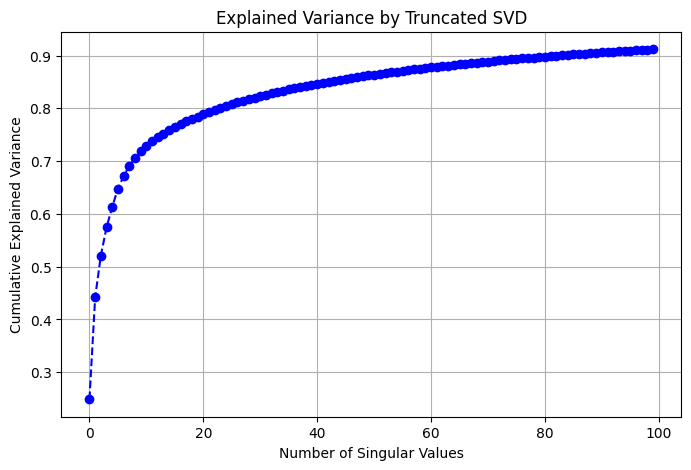

In [16]:
# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Truncated SVD")
plt.grid()
plt.show()

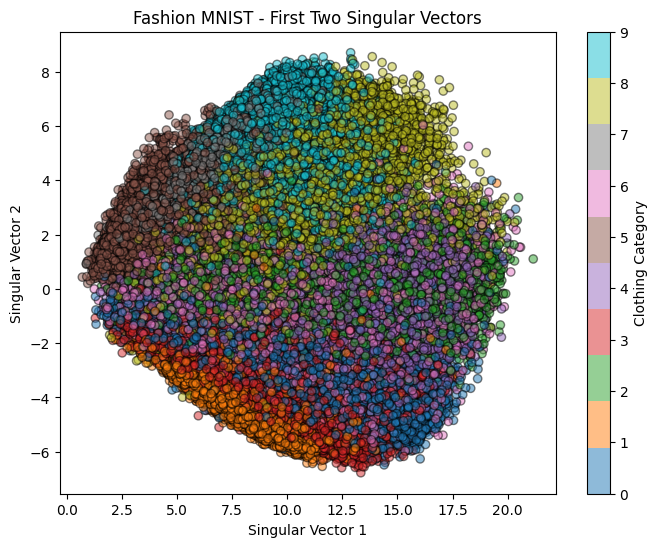

In [17]:
# Visualizing the first two components
plt.figure(figsize=(8, 6))
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y, cmap='tab10', alpha=0.5, edgecolors='k')
plt.xlabel("Singular Vector 1")
plt.ylabel("Singular Vector 2")
plt.title("Fashion MNIST - First Two Singular Vectors")
plt.colorbar(label="Clothing Category")
plt.show()

Here is is what you should note; 

- Truncated SVD effectively reduces dimensionality while preserving key features.
- Works well for high-dimensional data like images.
- The explained variance plot shows how many components are needed for a good representation.
- The scatter plot illustrates how different fashion items are clustered in a lower-dimensional space.

### t-SNE

t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique mainly used for visualizing high-dimensional data in 2D or 3D. Unlike PCA or Truncated SVD, which focus on preserving global structures (like variance), t-SNE preserves local structures, meaning that similar data points stay close together.

In [18]:
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

In [19]:
# Load Fashion MNIST dataset
fashion_mnist = fetch_openml('Fashion-MNIST', version=1)
X, y = fashion_mnist.data, fashion_mnist.target.astype(int)

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled[:5000])  # Using a subset for efficiency

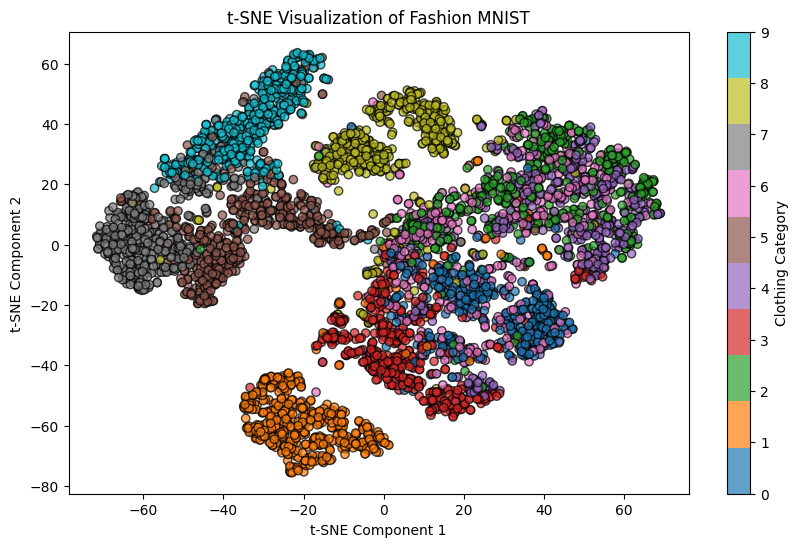

In [21]:
# Plot the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y[:5000], cmap='tab10', alpha=0.7, edgecolors='k')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Fashion MNIST")
plt.colorbar(scatter, label="Clothing Category")
plt.show()

Here is what you should note; 

- t-SNE is excellent for visualizing complex datasets in 2D or 3D.
- It helps in discovering clusters in data (e.g., grouping similar clothing types).
- Unlike PCA, which captures variance, t-SNE focuses on local relationships (keeping similar points close).
- It is computationally expensive, so we usually apply it to a subset of data.

### **UMAP**

UMAP (Uniform Manifold Approximation and Projection) is a dimensionality reduction technique that helps visualize high-dimensional data in 2D or 3D while maintaining both local and global structures better than t-SNE. It is faster and scales better than t-SNE, making it useful for large datasets.

In [22]:
import umap
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [23]:
# Load Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

In [24]:
# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
# Apply UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

/home/the-ape/CurrentProjects/whatsapp-business/DSAI-course/DSAI_env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/the-ape/CurrentProjects/whatsapp-business/DSAI-course/DSAI_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


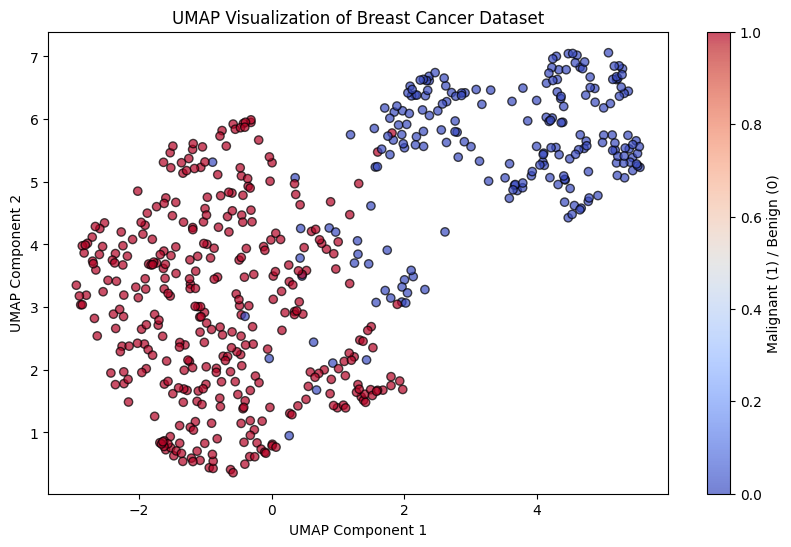

In [26]:
# Plot the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("UMAP Visualization of Breast Cancer Dataset")
plt.colorbar(scatter, label="Malignant (1) / Benign (0)")
plt.show()

UMAP is great for dimensionality reduction, similar to t-SNE, but faster and more scalable.

It preserves both local (similar points) and global (overall structure) relationships better.

Works well for large datasets and can be used for visualization or feature engineering.

# Hands-on Using titanic dataset

In [44]:
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")

# Load dataset 
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [45]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [46]:
titanic["age"].fillna(titanic["age"].mean(), inplace=True) # Fill age by mean 
titanic["embarked"].ffill(inplace=True)
titanic["deck"] = titanic["deck"].ffill().bfill()
titanic["embark_town"].ffill(inplace=True)

In [47]:
titanic.isna().sum().sum()

np.int64(0)

In [48]:
from sklearn.preprocessing import LabelEncoder
# select non numeric variables 
t1 = titanic.select_dtypes(include=["bool", "object", "category"]) 

for col in t1.columns:
    le = LabelEncoder() # An instance of label encorder
    titanic[col] = le.fit_transform(titanic[col])

In [49]:
titanic.dtypes

survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked         int64
class            int64
who              int64
adult_male       int64
deck             int64
embark_town      int64
alive            int64
alone            int64
dtype: object

In [50]:
# Split into independent(predctor) and dependent(target) variables
X = titanic.drop("survived", axis=1) # independent variables 
y = titanic["survived"] # dependent variables 

In [51]:
from sklearn.model_selection import train_test_split

# Split into train and test datasets 
X_train, y_train, X_test, y_test = train_test_split(X, y, 
                                                    test_size=0.2)

In [52]:
X.shape

(891, 14)

In [56]:
from sklearn.decomposition import PCA

# Apply PCA as an example of Dimensionality Reduction
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X)

In [57]:
X_pca.shape

(891, 2)

In [58]:
from sklearn.linear_model import LogisticRegression

logReg = LogisticRegression()
logReg.fit(X_pca, y)
logReg.score(X_pca, y)

0.6565656565656566

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier()
rf_clf.fit(X_pca, y)
rf_clf.score(X_pca, y)

1.0

In [60]:
from sklearn.svm import SVC # Support Vector Machine Classifier

svc = SVC()
svc.fit(X_pca, y)
svc.score(X_pca, y)

0.6801346801346801